In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from tqdm import tqdm
import os
import json

## Dataset

In [2]:
class DrugTargetDataset(Dataset):
    """Dataset for drug-target pairs with pre-computed embeddings"""
    
    def __init__(self, csv_path, drug_embeds_path, target_embeds_path):
        self.data = pd.read_csv(csv_path)
        
        # Load embeddings
        self.drug_embeds = torch.load(drug_embeds_path)
        self.target_embeds = torch.load(target_embeds_path)
        
        # Filter data to only include pairs where both embeddings exist
        valid_indices = []
        for idx, row in self.data.iterrows():
            if row['SMILES'] in self.drug_embeds and row['Protein'] in self.target_embeds:
                valid_indices.append(idx)
        
        self.data = self.data.iloc[valid_indices].reset_index(drop=True)
        print(f"Loaded {len(self.data)} valid drug-target pairs")
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        drug_embed = self.drug_embeds[row['SMILES']]
        target_embed = self.target_embeds[row['Protein']]
        
        return {
            'drug': drug_embed,
            'target': target_embed,
            'smile': row['SMILES'],
            'protein': row['Protein']
        }

In [4]:
train_dataset = DrugTargetDataset(
    '/ix1/ychiu/yil346/DTI_v2/Structure/Contrastive_learning/data/processed/random_split/train_pairs.csv',
    '/ix1/ychiu/yil346/DTI_v2/Structure/Contrastive_learning/data/embeddings/SMILE_embedding.pt',   
    '/ix1/ychiu/yil346/DTI_v2/Structure/Contrastive_learning/data/embeddings/protein_embedding.pt'
)

/scratch/slurm-1562169/ipykernel_3725516/1234656406.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.drug_embeds = torch.load(drug_embeds_path)
/scratch/slurm-156216

Loaded 116267 valid drug-target pairs


In [3]:
test_dataset = DrugTargetDataset(
    '/ix1/ychiu/yil346/DTI_v2/Structure/Contrastive_learning/data/processed/random_split/test_pairs.csv',
    '/ix1/ychiu/yil346/DTI_v2/Structure/Contrastive_learning/data/embeddings/SMILE_embedding.pt',   
    '/ix1/ychiu/yil346/DTI_v2/Structure/Contrastive_learning/data/embeddings/protein_embedding.pt'
)

/scratch/slurm-1604521/ipykernel_2684329/1234656406.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.drug_embeds = torch.load(drug_embeds_path)
/scratch/slurm-160452

Loaded 29067 valid drug-target pairs


## Projection Head

In [4]:
class ProjectionHead(nn.Module):
    """Deeper MLP projection head for contrastive learning."""
    
    def __init__(self, input_dim, hidden_dim=1024, output_dim=512, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim // 2, output_dim)
        )
    
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


In [4]:
class ProjectionHead(nn.Module):
    """Projection head to map embeddings to contrastive learning space"""
    
    def __init__(self, input_dim, hidden_dim=1024, output_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

## Model

In [5]:
class ContrastiveModel(nn.Module):
    """Contrastive learning model for drug-target alignment"""
    
    def __init__(self, drug_dim, target_dim, hidden_dim=1024, output_dim=512):
        super().__init__()
        self.drug_projector = ProjectionHead(drug_dim, hidden_dim, output_dim)
        self.target_projector = ProjectionHead(target_dim, hidden_dim, output_dim)
        
    def forward(self, drug_embeds, target_embeds):
        drug_proj = self.drug_projector(drug_embeds)
        target_proj = self.target_projector(target_embeds)
        return drug_proj, target_proj

## Loss function

In [8]:
class InfoNCELoss(nn.Module):
    """InfoNCE loss for contrastive learning"""
    
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature
        
    def forward(self, drug_proj, target_proj):
        """
        Compute bidirectional InfoNCE loss
        Args:
            drug_proj: [batch_size, proj_dim] normalized drug projections
            target_proj: [batch_size, proj_dim] normalized target projections
        """
        batch_size = drug_proj.shape[0]
        
        # Compute similarity matrix
        # [batch_size, batch_size]
        logits = torch.matmul(drug_proj, target_proj.T) / self.temperature
        
        # Labels: diagonal elements are positive pairs
        labels = torch.arange(batch_size, device=drug_proj.device)
        
        # Drug-to-target loss
        loss_d2t = F.cross_entropy(logits, labels)
        
        # Target-to-drug loss
        loss_t2d = F.cross_entropy(logits.T, labels)
        
        # Symmetric loss
        loss = (loss_d2t + loss_t2d) / 2
        
        return loss

## Compute metrics during training

In [9]:
def compute_alignment_metrics(drug_proj, target_proj):
    """
    Compute alignment metrics for a batch
    Args:
        drug_proj: [batch_size, proj_dim] normalized projections
        target_proj: [batch_size, proj_dim] normalized projections
    Returns:
        dict with metrics
    """
    batch_size = drug_proj.shape[0]
    
    # Compute full similarity matrix
    sim_matrix = torch.matmul(drug_proj, target_proj.T)  # [batch_size, batch_size]
    
    # Positive similarities (diagonal)
    pos_sim = torch.diagonal(sim_matrix)  # [batch_size]
    
    # Negative similarities (off-diagonal)
    # Create mask for diagonal
    mask = torch.eye(batch_size, device=drug_proj.device).bool()
    neg_sim = sim_matrix[~mask]  # [batch_size * (batch_size - 1)]
    
    metrics = {
        'pos_sim_mean': pos_sim.mean().item(),
        'pos_sim_std': pos_sim.std().item(),
        'neg_sim_mean': neg_sim.mean().item(),
        'neg_sim_std': neg_sim.std().item(),
        'gap': (pos_sim.mean() - neg_sim.mean()).item(),
        'alignment': pos_sim.mean().item()  # Average alignment score
    }
    
    return metrics

## Training

In [10]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    
    # Metrics accumulators
    metrics_accumulator = {'pos_sim_mean': 0,'neg_sim_mean': 0,'gap': 0,'alignment': 0}
    
    for batch in tqdm(dataloader, desc="Training"):
        drug_embeds = batch['drug'].to(device)
        target_embeds = batch['target'].to(device)
        
        # Forward pass
        drug_proj, target_proj = model(drug_embeds, target_embeds)
        
        # Compute loss
        loss = criterion(drug_proj, target_proj)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Compute metrics (no grad needed)
        with torch.no_grad():
            batch_metrics = compute_alignment_metrics(drug_proj, target_proj)
            for key in metrics_accumulator:
                metrics_accumulator[key] += batch_metrics[key]
    
    # Average metrics
    avg_loss = total_loss / len(dataloader)
    avg_metrics = {k: v / len(dataloader) for k, v in metrics_accumulator.items()}
    
    return avg_loss, avg_metrics

In [11]:
def validate(model, dataloader, criterion, device):
    """Validate the model"""
    model.eval()
    total_loss = 0
    
    # Metrics accumulators
    metrics_accumulator = {'pos_sim_mean': 0,'neg_sim_mean': 0,'gap': 0,'alignment': 0}
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating"):
            drug_embeds = batch['drug'].to(device)
            target_embeds = batch['target'].to(device)
            
            drug_proj, target_proj = model(drug_embeds, target_embeds)
            loss = criterion(drug_proj, target_proj)
            
            total_loss += loss.item()
            
            # Compute metrics
            batch_metrics = compute_alignment_metrics(drug_proj, target_proj)
            for key in metrics_accumulator:
                metrics_accumulator[key] += batch_metrics[key]
    
    avg_loss = total_loss / len(dataloader)
    avg_metrics = {k: v / len(dataloader) for k, v in metrics_accumulator.items()}
    
    return avg_loss, avg_metrics

In [12]:
def main():
    # Configuration
    config = {
        'batch_size': 256,
        'learning_rate': 1e-4,
        'num_epochs': 30,
        'hidden_dim': 1024,
        'output_dim': 512,
        'temperature': 0.10,
        'weight_decay': 1e-5,
        'save_dir': '/ix1/ychiu/yil346/DTI_v2/Structure/Contrastive_learning/result/1229_0',
        'device': 'cuda' if torch.cuda.is_available() else 'cpu'
    }
    
    print(f"Using device: {config['device']}")
     
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    val_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

    
    # Get embedding dimensions from first sample
    sample = train_dataset[0]
    drug_dim = sample['drug'].shape[0]
    target_dim = sample['target'].shape[0]
    print(f"Drug embedding dim: {drug_dim}, Target embedding dim: {target_dim}")
    
    # Initialize model
    model = ContrastiveModel(drug_dim=drug_dim, target_dim=target_dim, hidden_dim=config['hidden_dim'], output_dim=config['output_dim']).to(config['device'])
    
    # Loss and optimizer
    criterion = InfoNCELoss(temperature=config['temperature'])
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config['num_epochs']
    )
    
    # Training loop
    best_val_loss = float('inf')
    history = []
    
    for epoch in range(config['num_epochs']):
        print(f"\nEpoch {epoch+1}/{config['num_epochs']}")
        
        train_loss, train_metrics = train_epoch(model, train_loader, optimizer, criterion, config['device'])
        val_loss, val_metrics = validate(model, val_loader, criterion, config['device'])
        
        scheduler.step()
        
        # Save to history
        epoch_record = {
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_pos': train_metrics['pos_sim_mean'],
            'train_neg': train_metrics['neg_sim_mean'],
            'train_gap': train_metrics['gap'],
            'train_alignment': train_metrics['alignment'],
            'val_loss': val_loss,
            'val_pos': val_metrics['pos_sim_mean'],
            'val_neg': val_metrics['neg_sim_mean'],
            'val_gap': val_metrics['gap'],
            'val_alignment': val_metrics['alignment']
        }
        history.append(epoch_record)
        
        # Print loss
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        
        # Print alignment metrics
        print(f"Train Metrics - Pos Sim: {train_metrics['pos_sim_mean']:.4f}, "
              f"Neg Sim: {train_metrics['neg_sim_mean']:.4f}, "
              f"Gap: {train_metrics['gap']:.4f}, "
              f"Alignment: {train_metrics['alignment']:.4f}")
        
        print(f"Val Metrics   - Pos Sim: {val_metrics['pos_sim_mean']:.4f}, "
              f"Neg Sim: {val_metrics['neg_sim_mean']:.4f}, "
              f"Gap: {val_metrics['gap']:.4f}, "
              f"Alignment: {val_metrics['alignment']:.4f}")
        

        # ---- Save best model ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f"{config['save_dir']}/best_model.pt")
            print(f"🏆 New best model saved (val_loss={val_loss:.4f})")
        
        # Save history every epoch
        with open('training_history.json', 'w') as f:
            json.dump(history, f, indent=2)
    
    print("\nTraining completed!")
    print(f"Best validation loss: {best_val_loss:.4f}")
    print(f"Training history saved to: training_history.json")

In [13]:
if __name__ == '__main__':
    main()

Using device: cuda
Drug embedding dim: 384, Target embedding dim: 1280

Epoch 1/30


Validating: 100%|██████████| 114/114 [00:01<00:00, 88.85it/s]


Train Loss: 4.1825, Val Loss: 3.7804
Train Metrics - Pos Sim: 0.2462, Neg Sim: 0.0046, Gap: 0.2415, Alignment: 0.2462
Val Metrics   - Pos Sim: 0.3069, Neg Sim: 0.0017, Gap: 0.3053, Alignment: 0.3069
🏆 New best model saved (val_loss=3.7804)

Epoch 2/30


Validating: 100%|██████████| 114/114 [00:01<00:00, 88.66it/s]


Train Loss: 3.5232, Val Loss: 3.5067
Train Metrics - Pos Sim: 0.3455, Neg Sim: -0.0011, Gap: 0.3465, Alignment: 0.3455
Val Metrics   - Pos Sim: 0.3573, Neg Sim: 0.0041, Gap: 0.3532, Alignment: 0.3573
🏆 New best model saved (val_loss=3.5067)

Epoch 3/30


...

Train Loss: 2.3228, Val Loss: 2.8361
Train Metrics - Pos Sim: 0.5172, Neg Sim: -0.0016, Gap: 0.5188, Alignment: 0.5172
Val Metrics   - Pos Sim: 0.4625, Neg Sim: 0.0013, Gap: 0.4612, Alignment: 0.4625

Epoch 29/30


Validating: 100%|██████████| 114/114 [00:01<00:00, 88.83it/s]


Train Loss: 2.3195, Val Loss: 2.8350
Train Metrics - Pos Sim: 0.5177, Neg Sim: -0.0016, Gap: 0.5193, Alignment: 0.5177
Val Metrics   - Pos Sim: 0.4617, Neg Sim: 0.0005, Gap: 0.4613, Alignment: 0.4617
🏆 New best model saved (val_loss=2.8350)

Epoch 30/30


Validating: 100%|██████████| 114/114 [00:01<00:00, 89.02it/s]


Train Loss: 2.3157, Val Loss: 2.8343
Train Metrics - Pos Sim: 0.5179, Neg Sim: -0.0016, Gap: 0.5195, Alignment: 0.5179
Val Metrics   - Pos Sim: 0.4619, Neg Sim: 0.0002, Gap: 0.4617, Alignment: 0.4619
🏆 New best model saved (val_loss=2.8343)

Training completed!
Best validation loss: 2.8343
Training history saved to: training_history.json


## Inference

In [6]:
import random
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np
import umap
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [7]:
device = 'cpu'
model = ContrastiveModel(drug_dim = 384, target_dim = 1280, hidden_dim=1024, output_dim=512)
model.load_state_dict(torch.load("/ix1/ychiu/yil346/DTI_v2/Structure/Contrastive_learning/result/1229_0/best_model.pt", map_location=device))
model.to(device)
model.eval()

/scratch/slurm-1604521/ipykernel_2684329/1496044081.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/ix1/ychiu/yil346/DTI_v2/Structure/

ContrastiveModel(
  (drug_projector): ProjectionHead(
    (net): Sequential(
      (0): Linear(in_features=384, out_features=1024, bias=True)
      (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=1024, out_features=512, bias=True)
    )
  )
  (target_projector): ProjectionHead(
    (net): Sequential(
      (0): Linear(in_features=1280, out_features=1024, bias=True)
      (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=1024, out_features=512, bias=True)
    )
  )
)

In [8]:
device = 'cpu'
model.to(device)
model.eval()

val_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

all_drug_embs, all_target_embs = [], []
org_drug_embs, org_target_embs = [], []

with torch.no_grad():
    for batch in val_loader:
        # Match your dataset keys
        drug_emb = batch["drug"].to(device)
        target_emb = batch["target"].to(device)

        # Pass through your trained projection model
        drug_features, target_features = model(drug_emb, target_emb)

        # Store results
        all_drug_embs.append(drug_features.cpu())
        all_target_embs.append(target_features.cpu())
        org_drug_embs.append(drug_emb.cpu())
        org_target_embs.append(target_emb.cpu())

In [9]:
all_drug_embs = torch.cat(all_drug_embs, dim=0)
all_target_embs = torch.cat(all_target_embs, dim=0)

print(f" Drug embeddings: {all_drug_embs.shape}")
print(f" Target embeddings: {all_target_embs.shape}")

org_drug_embs = torch.cat(org_drug_embs, dim=0)
org_target_embs = torch.cat(org_target_embs, dim=0)

 Drug embeddings: torch.Size([29067, 512])
 Target embeddings: torch.Size([29067, 512])


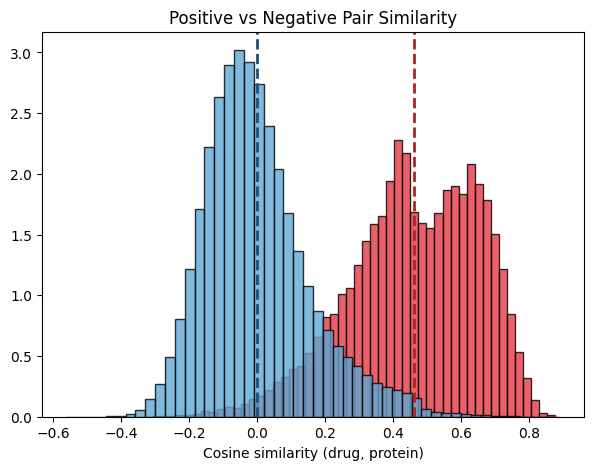

In [10]:
plt.figure(figsize=(7, 5))

pos_sims = F.cosine_similarity(all_drug_embs, all_target_embs).cpu().numpy()
sim_matrix = (all_drug_embs @ all_target_embs.T).cpu().numpy()
neg_sims = sim_matrix[~np.eye(sim_matrix.shape[0], dtype=bool)].flatten() # remove diagnoal

pos_mean = np.mean(pos_sims)
neg_mean = np.mean(neg_sims)

plt.hist(pos_sims, bins=50, color='#e63946', alpha=0.8, label='Positive', density=True, edgecolor='black')
plt.hist(neg_sims, bins=50, color='#5fa8d3', alpha=0.8, label='Negative', density=True, edgecolor='black')

plt.axvline(pos_mean, color='#b22222', linestyle='--', linewidth=2, label=f'Pos mean = {pos_mean:.3f}')
plt.axvline(neg_mean, color='#1f4e79', linestyle='--', linewidth=2, label=f'Neg mean = {neg_mean:.3f}')

#plt.legend()
plt.xlabel("Cosine similarity (drug, protein)")
plt.title("Positive vs Negative Pair Similarity")
#plt.savefig("/ix1/ychiu/yil346/DTI_v2/plot/structure_cosine_similarity_distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
from scipy import stats

print(np.mean(pos_sims), np.std(pos_sims))
print(np.mean(neg_sims), np.std(neg_sims))

t_stat, p_value = stats.ttest_ind(pos_sims, neg_sims)
print("t-statistic:", t_stat)
print("p-value:", p_value)

u_stat, p_value = stats.mannwhitneyu(pos_sims, neg_sims, alternative='two-sided')
print("U statistic:", u_stat)
print("p-value:", p_value)

t-statistic: 502.3474750561125
p-value: 0.0
U statistic: 23539444023833.0
p-value: 0.0
